# RFM Analysis-Customer Segmentation

This project aims to look into the customer's behavior, by studying the RFM segmentation. RFM (Recency, Frequency, Monetary value) analysis is a marketing method of customer segmentation. It evaluates the purchasing behavior of each customer through three key criteria to identify the most valuable and adapt commercial actions.

**Data Set Information:** This Online Retail II data set contains all the transactions occurring for a UK-based and registered, non-store online retail between 01/12/2009 and 09/12/2011.The company mainly sells unique all-occasion gift-ware. Many customers of the company are wholesalers.

**Stack :** Python, pandas, scikit-learn, seaborn, matplotlib

## Sommaire
1. Import et chargement des données
2. Exploration initiale (EDA)
3. Nettoyage des données
4. Calcul des métriques RFM
5. Scoring et segmentation
6. Visualisations
7. Insights business et recommandations

## 1. Import and configuration

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")


df = pd.read_csv("/Users/aminkaabi/Downloads/online_retail_II.csv", encoding="latin-1")
print(f"Dataset chargé : {df.shape[0]:,} lignes, {df.shape[1]} colonnes")

Dataset chargé : 541,910 lignes, 8 colonnes


## 2. EDA

### 2.1 Data structure

In [63]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      541910 non-null  str    
 1   StockCode    541910 non-null  str    
 2   Description  540456 non-null  str    
 3   Quantity     541910 non-null  int64  
 4   InvoiceDate  541910 non-null  str    
 5   Price        541910 non-null  float64
 6   Customer ID  406830 non-null  float64
 7   Country      541910 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


,Quantity,Price,Customer ID
count,541910.000000,541910.000000,406830.000000
mean,9.552234,4.611138,15287.684160
std,218.080957,96.759765,1713.603074
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


The distribution of 'Quantity' is strongly asymmetric to the right: some transactions with extremely high quantities pull the average upwards. Same thing with the 'Price', the mean is much higher than the median, so there are probably some transactions with very high prices that pull the average up. For the two features a negative quantity probably corresponds to returns/cancellations, this has to be cleaned afterwards.

In [64]:
df.describe(include="object")

,Invoice,StockCode,Description,InvoiceDate,Country
count,541910,541910,540456,541910,541910
unique,25900,4070,4223,23260,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,10/31/11 14:41,United Kingdom
freq,1114,2313,2369,1114,495478


This indicate our best seller and most of our customers are from the UK, that mean

### 2.2 Missing values

In [65]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'Missing': missing, '%': missing_pct})

,Missing,%
Invoice,0,0.00
StockCode,0,0.00
Description,1454,0.27
Quantity,0,0.00
InvoiceDate,0,0.00
Price,0,0.00
Customer ID,135080,24.93
Country,0,0.00


## 3. Cleaning

In [66]:
# Step 1 : Delete rows without Customer ID
df = df.dropna(subset=['Customer ID'])
print(f"After suppression NaN Customer ID : {len(df):,} rows")

# Step 2 : Delete negatives values (returns)
df = df[df['Quantity'] > 0]
print(f"After suppression returns : {len(df):,} rows")

# Step 3 : Delete negatives or equals 0 prices
df = df[df['Price'] > 0]
print(f"After suppression invalid prices : {len(df):,} rows")

# Step 4 : Convert dates
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Customer ID'] = df['Customer ID'].astype(int)

print(f"\nDataset final cleaned : {len(df):,} rows")

After suppression NaN Customer ID : 406,830 rows
After suppression returns : 397,925 rows
After suppression invalid prices : 397,885 rows

Dataset final cleaned : 397,885 rows


## 4. RFM calculation

- **Recency (R)** : days after the last order
- **Frequency (F)** : numbers of unique orders
- **Monetary value (M)** : total value per customers

In [67]:
date_ref = df['InvoiceDate'].max() + pd.Timedelta(days=1)
df['CA'] = df['Quantity'] * df['Price']

rfm = df.groupby('Customer ID').agg(
    Recency   = ('InvoiceDate', lambda x: (date_ref - x.max()).days),
    Frequency = ('Invoice',     'nunique'),
    Revenue   = ('CA',          'sum')
).reset_index()

print(rfm.describe().round(2))

       Customer ID  Recency  Frequency    Revenue
count      4338.00  4338.00    4338.00    4338.00
mean      15300.41    92.54       4.27    2054.27
std        1721.81   100.01       7.70    8989.23
min       12346.00     1.00       1.00       3.75
25%       13813.25    18.00       1.00     307.41
50%       15299.50    51.00       2.00     674.48
75%       16778.75   142.00       5.00    1661.74
max       18287.00   374.00     209.00  280206.02


## 5. Scoring and segmentation

In [68]:


# Step 1. Compute R, F, M scores (1 to 5)
# Recency : lower is better → reversed labels [5,4,3,2,1]


rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1],
                          duplicates='drop')

rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'),
                          5, labels=[1, 2, 3, 4, 5],
                          duplicates='drop')

rfm['M_score'] = pd.qcut(rfm['Revenue'].rank(method='first'),
                          5, labels=[1, 2, 3, 4, 5],
                          duplicates='drop')

# Step 2. Concatenate into a single RFM score string
rfm['RFM_score'] = (rfm['R_score'].astype(str) +
                    rfm['F_score'].astype(str) +
                    rfm['M_score'].astype(str))

# Step 3. Business segmentation based on R and F scores
def assign_segment(row):
    r = int(row['R_score'])
    f = int(row['F_score'])
    if r >= 4 and f >= 4:   return 'Champions'
    elif r >= 3 and f >= 3: return 'Loyal Customers'
    elif r >= 4 and f <= 2: return 'New Customers'
    elif r <= 2 and f >= 3: return 'At Risk of Churn'
    else:                   return 'Lost Customers'

rfm['Segment'] = rfm.apply(assign_segment, axis=1)

# Step 4. Segment overview
segment_summary = rfm.groupby('Segment').agg(
    Customer_Count = ('Customer ID', 'count'),
    Total_Revenue  = ('Revenue',     'sum'),
    Avg_Revenue    = ('Revenue',     'mean'),
    Avg_Recency    = ('Recency',     'mean'),
    Avg_Frequency  = ('Frequency',   'mean')
).round(2)

segment_summary['Revenue_%'] = (
    segment_summary['Total_Revenue'] /
    segment_summary['Total_Revenue'].sum() * 100
).round(1)

print("=" * 60)
print("CUSTOMER SEGMENTATION SUMMARY")
print("=" * 60)
print(segment_summary.sort_values('Total_Revenue', ascending=False))
print(f"\nTotal customers analysed : {len(rfm):,}")
print(f"Total revenue            : £{rfm['Revenue'].sum():,.0f}")

CUSTOMER SEGMENTATION SUMMARY
                  Customer_Count  Total_Revenue  Avg_Revenue  Avg_Recency  \
Segment                                                                     
Champions                   1139     5927741.91      5204.34        13.31   
Loyal Customers              821     1355744.71      1651.33        38.04   
At Risk of Churn             643      800531.55      1244.99       152.84   
Lost Customers              1416      681241.16       481.10       177.15   
New Customers                319      146166.57       458.20        18.52   

                  Avg_Frequency  Revenue_%  
Segment                                     
Champions                  9.99       66.5  
Loyal Customers            3.64       15.2  
At Risk of Churn           3.40        9.0  
Lost Customers             1.12        7.6  
New Customers              1.24        1.6  

Total customers analysed : 4,338
Total revenue            : £8,911,426


## 6. Visualisations

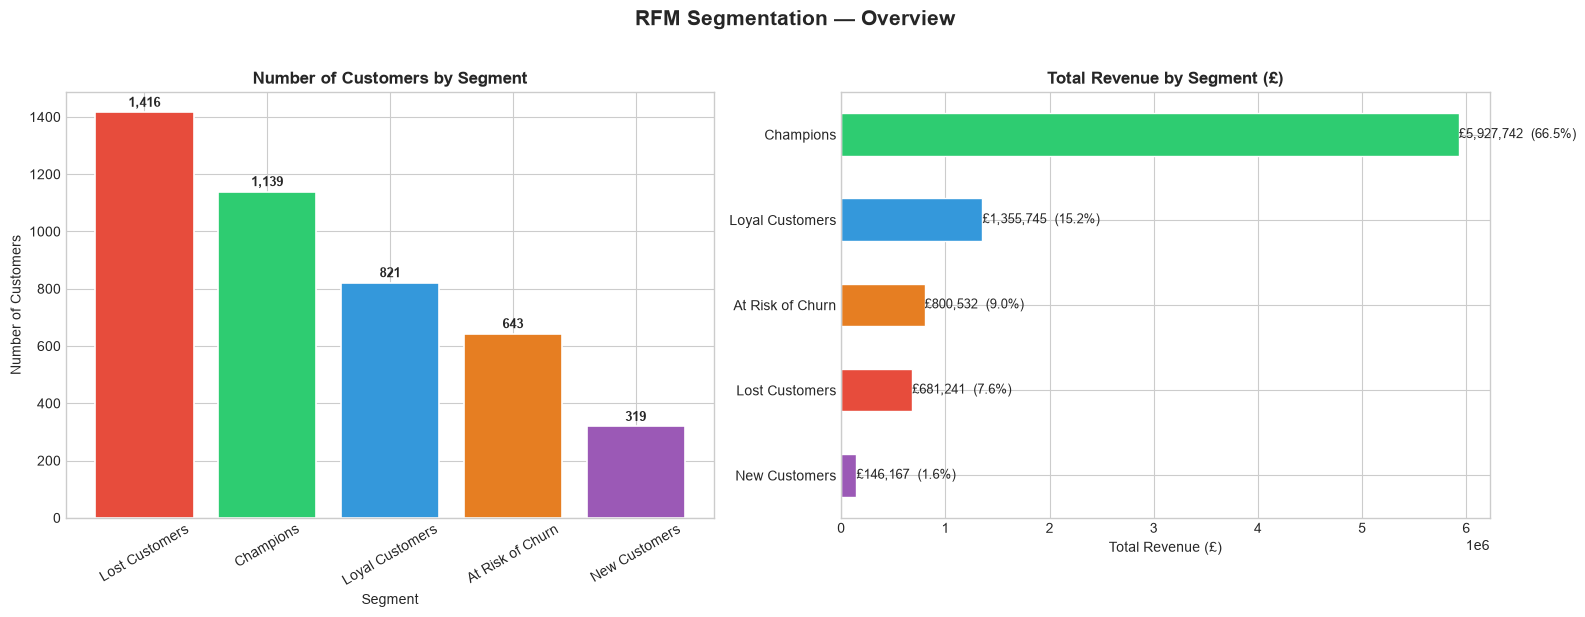

Figure 1 saved : fig1_segment_overview.png


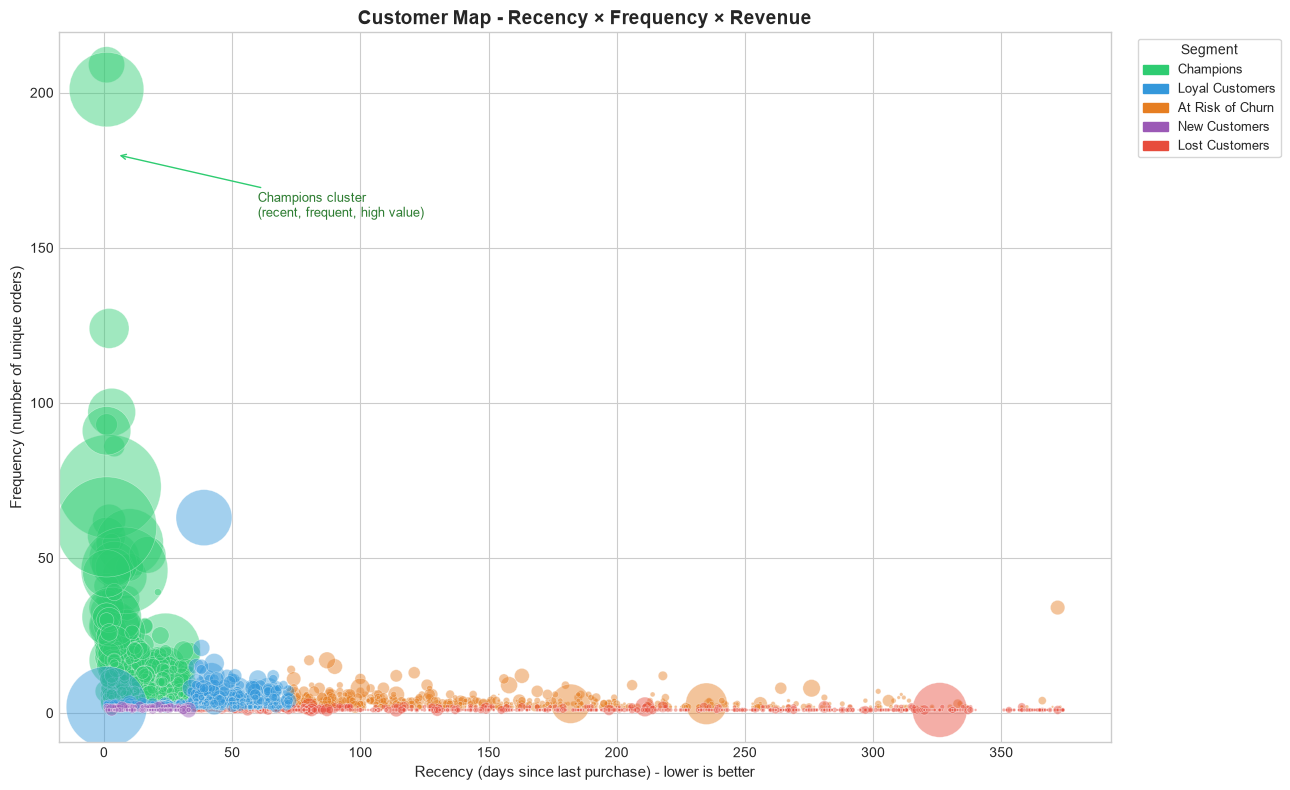

Figure 2 saved : fig2_customer_map.png


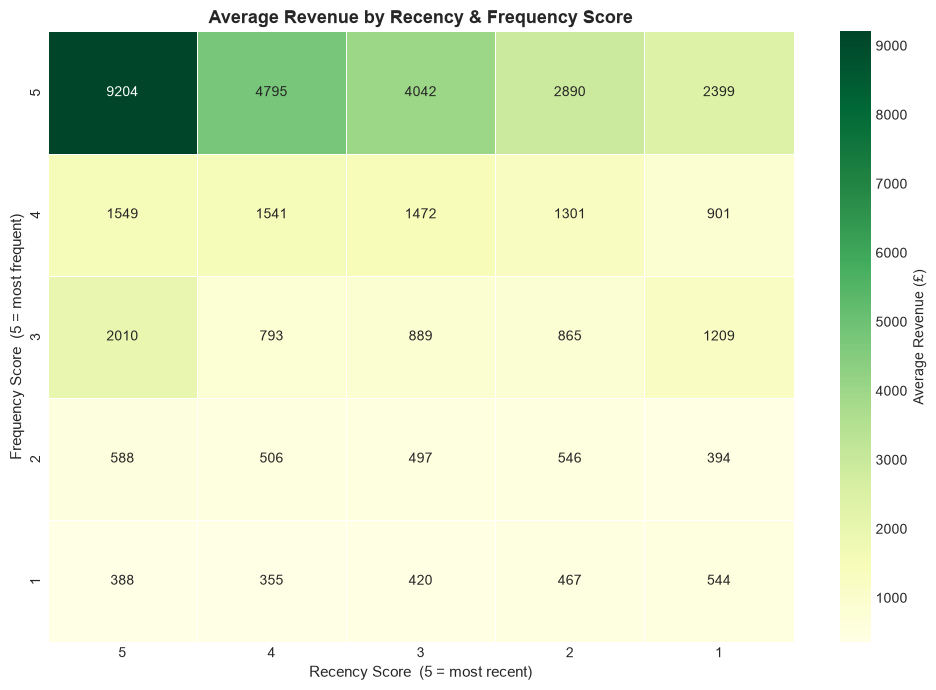

Figure 3 saved : fig3_rfm_heatmap.png

KEY INSIGHT
Champions represent 26.3% of customers
but generate      66.5% of total revenue.
→ Protecting this segment is the #1 business priority.


In [70]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

# Colour palette per segment
SEGMENT_COLORS = {
    'Champions':       '#2ecc71',
    'Loyal Customers': '#3498db',
    'At Risk of Churn':'#e67e22',
    'New Customers':   '#9b59b6',
    'Lost Customers':  '#e74c3c'
}


# FIGURE 1. Segment distribution & Revenue share

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('RFM Segmentation — Overview', fontsize=15,
             fontweight='bold', y=1.02)

# Chart 1 : Number of customers per segment
segment_counts = rfm['Segment'].value_counts()
colors_bar = [SEGMENT_COLORS[s] for s in segment_counts.index]

bars = axes[0].bar(segment_counts.index, segment_counts.values,
                   color=colors_bar, edgecolor='white', linewidth=1.2)
axes[0].set_title('Number of Customers by Segment',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Segment', fontsize=10)
axes[0].set_ylabel('Number of Customers', fontsize=10)
axes[0].tick_params(axis='x', rotation=30)

# Add count labels on bars
for bar, count in zip(bars, segment_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 10,
                 f'{count:,}', ha='center', va='bottom',
                 fontsize=9, fontweight='bold')

# Chart 2 : Revenue share per segment
rev_by_segment = rfm.groupby('Segment')['Revenue'].sum().sort_values()
colors_rev = [SEGMENT_COLORS[s] for s in rev_by_segment.index]

rev_by_segment.plot(kind='barh', ax=axes[1],
                    color=colors_rev, edgecolor='white')
axes[1].set_title('Total Revenue by Segment (£)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Total Revenue (£)', fontsize=10)
axes[1].set_ylabel('')

# Add revenue labels
for i, (val, name) in enumerate(zip(rev_by_segment.values,
                                     rev_by_segment.index)):
    pct = val / rev_by_segment.sum() * 100
    axes[1].text(val + 1000, i,
                 f'£{val:,.0f}  ({pct:.1f}%)',
                 va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../figures/fig1_segment_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 1 saved : fig1_segment_overview.png")


# FIGURE 2. Customer Map : Recency × Frequency × Revenue

fig, ax = plt.subplots(figsize=(13, 8))

for segment, group in rfm.groupby('Segment'):
    ax.scatter(
        group['Recency'],
        group['Frequency'],
        s=group['Revenue'] / 50,        # bubble size ∝ revenue
        alpha=0.45,
        color=SEGMENT_COLORS[segment],
        label=segment,
        edgecolors='white',
        linewidth=0.4
    )

ax.set_title('Customer Map - Recency × Frequency × Revenue',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Recency (days since last purchase) - lower is better',
              fontsize=11)
ax.set_ylabel('Frequency (number of unique orders)',
              fontsize=11)

# Legend
legend_patches = [
    mpatches.Patch(color=SEGMENT_COLORS[s], label=s)
    for s in SEGMENT_COLORS
]
ax.legend(handles=legend_patches, title='Segment',
          bbox_to_anchor=(1.02, 1), loc='upper left',
          frameon=True, fontsize=9)

# Annotation
ax.annotate('Champions cluster\n(recent, frequent, high value)',
            xy=(5, 180), xytext=(60, 160),
            arrowprops=dict(arrowstyle='->', color='#2ecc71'),
            fontsize=9, color='#2e7d32')

plt.tight_layout()
plt.savefig('../figures/fig2_customer_map.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 2 saved : fig2_customer_map.png")


# FIGURE 3. RFM Score Heatmap

fig, ax = plt.subplots(figsize=(10, 7))

# Average revenue per R/F score combination
heatmap_data = rfm.pivot_table(
    values='Revenue',
    index='F_score',
    columns='R_score',
    aggfunc='mean'
).iloc[::-1]   # flip F axis so 5 is at top

sns.heatmap(heatmap_data,
            annot=True,
            fmt='.0f',
            cmap='YlGn',
            linewidths=0.5,
            ax=ax,
            cbar_kws={'label': 'Average Revenue (£)'})

ax.set_title('Average Revenue by Recency & Frequency Score',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Recency Score  (5 = most recent)', fontsize=11)
ax.set_ylabel('Frequency Score  (5 = most frequent)', fontsize=11)

plt.tight_layout()
plt.savefig('../figures/fig3_rfm_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 3 saved : fig3_rfm_heatmap.png")


print("\n" + "=" * 60)
print("KEY INSIGHT")
print("=" * 60)
champions_pct = (rfm['Segment'] == 'Champions').mean() * 100
champions_rev = (rfm[rfm['Segment'] == 'Champions']['Revenue'].sum() /
                 rfm['Revenue'].sum() * 100)
print(f"Champions represent {champions_pct:.1f}% of customers")
print(f"but generate      {champions_rev:.1f}% of total revenue.")
print("→ Protecting this segment is the #1 business priority.")
print("=" * 60)

## 7. Insights business et recommandations

### Key result

**Champions (26% of customers) generate 66% of total turnover.**

This is the most critical concentration to watch.

### Recommandations par segment

| Segment        | Recomandations                             | Impact         |
|----------------|--------------------------------------------|----------------|
| Champions      | VIP programs, anticipated acces to newness | Retention      |
| Churn risks    | Reactivation campagn, discounts            | CA recovered   |
| Loyal customers | Cross-selling, pointsprograms              | Increase value |
| Losts customers | Selective boost (>500€ historic)           | ROI limitated  |
| New customers  | Neat onboarding, 2nd purchase encouraged   | LTV            |

### Limits of this analysis
- RFM scores are based on sensitive quantiles with extreme values
- No data on customer satisfaction or returns
- The segments are static, a dynamic analysis

Over 6 months would give more insights